# Plots for the paper

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ase.io import read
import matplotlib.pylab as pylab
from ase.units import kB

size=24
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [3]:
# get minima structure configurations
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.plots import plot_energy_surface
from ase.visualize.plot import plot_atoms
from flonacomldft.internal_coordinates import Coordinates_mapping

# load adaptive simulations
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data, load_ag6_image
from flonacomldft.utils.diagnostics import avg_windows

ag6_is0 = get_molecule_isomer_minima(name="is0")
ag6_is1 = get_molecule_isomer_minima(name="is1")

ag6_is0.center()
ag6_is1.center()

ag6_is0.translate([4, 0, 0])
ag6_is1.translate([11, 7, 7])

In [4]:
# 300 K results
# path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
# simulations = ["results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl",
#               "results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl"]

# 350 K results
path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = [#'2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [5]:
def cvs_from_adaptive(adaptive, isomer_id=0, etype='dft'):

    coord_mapping = Coordinates_mapping(etype='dft')

    xs = torch.cat(adaptive['xs']).detach()

    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = torch.cat(adaptive['isomers']).reshape(-1, 1)

    xs_is0 = []

    for isomer, x in zip(isomers_mask, xs_flatten):

        if (isomer[0]==isomer_id).item():
            xs_is0.append(x)

    xs_is0 = torch.stack(xs_is0)

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=isomer_id)

    return cvs_is0

In [6]:
def load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer=None):

    ag6_proposals = []
    for chain in range(n_chains):
        for step in range(n_steps):
            try:
            #print("ag6_{:d}_{:d}_{:d}.out".format(n_run, step, chain))
                ag6_proposals.append(read("{:s}DFTAdaptive/ag6_{:d}_{:d}_{:d}.out".format(path, n_run, step, chain)))
            except:
                continue
    coord_mapping = Coordinates_mapping()

    zmat = coord_mapping.get_internal_from_trajectory(ag6_proposals, isomer=isomer, temperature=300)
    xs = coord_mapping.get_real_centered_from_internal(zmat[:, :12], isomer=isomer, energies=zmat[:, 12])        
    
    return xs, zmat, ag6_proposals

def get_participation_ratio_from_dft_proposals(xs, us, model, kB, T):
    
    n_prop = xs.shape[0]
    
    log_weight = -us.squeeze()/(kB*T) + model.nll(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0)
    
    return torch.exp(-log_ratio) / n_prop 

def compute_part_ratios_per_adaptive(adaptive, path, isomer):

    part_ratios = []

    n_runs = 30#adaptive["args"]["n_runs"]
    n_chains = 20#adaptive["args"]["n_runs"]
    n_steps = 5#adaptive["args"]["n_steps"]

    for n_run in range(n_runs):
    
        model = adaptive["dict_flows_training"][n_run][0]['model']
        xs = load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer)[0]

        part_ratio = get_participation_ratio_from_dft_proposals(xs[0].float(), xs[2].float(), model, kB, 300)
    
        part_ratios.append(part_ratio)
        
    mcmc_steps = list(range(0, n_runs*n_steps, n_steps))
        
    return torch.stack(part_ratios), mcmc_steps

In [7]:
def plot_figure_1(plot_data, colors):

    keys = plot_data['keys']
    
    fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(40, 20), gridspec_kw={'width_ratios': [1.6, 1, 1]})
    gs = axs[0, 0].get_gridspec()
    # remove the underlying axes
    for ax in axs[0:, 0]:
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :1])

    
    #==== PLOT CVS
    
    for key in keys:
        axbig.scatter(plot_data['cvs'][key][:, 0].detach().numpy(), 
                        plot_data['cvs'][key][:, 1].detach().numpy(), 
                        c=colors[key], 
                        label=key)

    axbig.set_xlabel('Coordination number')
    axbig.set_ylabel('Radius of gyration')

    axbig.legend()
    
    #==== PLOT Isomer image

    l, b, h, w = .05, .05, .2, .1
    ax2 = fig.add_axes([l, b, w, h])
    ax2.imshow(load_ag6_image(plot_data['isomer']))
    ax2.set_xticks([])
    ax2.set_yticks([])

    #==== PLOT US vs NLL
    # review n_start
    for key in keys:
        axs[0][1].scatter(plot_data['us'][key].flatten().detach().numpy(), 
                      plot_data['nlls'][key].flatten().detach().numpy(), 
                      c=colors[key], 
                      label=key)

    axs[0][1].set_ylabel("Negative log likelihood [u.a]")
    axs[0][1].set_xlabel("Potential energy [e.V]")
    axs[0][1].legend()

    # PLOT energies histogram

    sns.histplot(plot_data['energies'], ax=axs[0][2], kde=False, stat="density", color=colors, bins=20)
    axs[0][2].set_xlabel("Potential energy [e.V]")

    # PLOT acceptance ratio

    for key in keys:
        set_plot_sequential_data(plot_data['accs'][key], 
                             avg=True, 
                             window_size=50, 
                             color=colors[key], 
                             ax=axs[1][1], 
                             linewidth=2.5, 
                             alpha=0.1,
                             label=key)

    axs[1][1].legend()
    axs[1][1].set_ylabel("Acceptance ratio")
    axs[1][1].set_xlabel("MCMC steps")
    
    # PLOT energies histogram

    axs[1][2].set_ylabel("Participation ratio")
    axs[1][2].set_xlabel("MCMC steps")

    for key in keys:
        axs[1][2].plot(plot_data['part_ratios'][key][1], 
                        plot_data['part_ratios'][key][0].detach().numpy(), 
                        color=colors[key], 
                        label=key)

# Add title

    fig.suptitle("Ab-initio flowMC - Isomer {:d}".format(plot_data['isomer']), 
                 fontsize=48)
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)

In [8]:
def get_info_from_adaptive(adaptive, path, isomer):
    
    accs = torch.cat(adaptive['accs']).mean(axis=1)
    us = torch.cat(adaptive['us'])
    xs = torch.cat(adaptive['xs'])

    cvs = cvs_from_adaptive(adaptive, isomer_id=isomer)

    part_ratios = compute_part_ratios_per_adaptive(adaptive, path, isomer)

    flow_models = adaptive["dict_flows_training"]

    nlls = []
    for i in range(30):
        nll = []
        for x in adaptive['xs'][i]:
            nll.append(flow_models[i][0]['model'].nll(x))
        nll = torch.stack(nll)
        nlls.append(nll)

    to_return = {
        'accs' : accs,
        'us' : us,
        'nlls' : nlls,
        'part_ratios' : part_ratios,
        'cvs' : cvs,
    }

    return to_return

## Adaptive one isomer.

In [9]:
keys = ['ab-inito flowMC w.o NP', 'ab-inito flowMC']
color_keys = dict(zip(keys, ['blue', 'orange']))

In [10]:
adaptives_is0 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[0], adaptive_mlp_path[0]])}
adaptives_is1 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[1], adaptive_mlp_path[1]])}

In [11]:
adaptive_path_is0 = {keys[0]: adaptive_dft_path[0],
                     keys[1]: adaptive_mlp_path[0]}

adaptive_path_is1 = {keys[0]: adaptive_dft_path[1],
                     keys[1]: adaptive_mlp_path[1]}

In [12]:
adaptive_info_is0 = {key: get_info_from_adaptive(adaptives_is0[key], 
                                                 path + '/' + adaptive_path_is0[key].split('/')[0] + '/' + adaptive_path_is0[key].split('/')[1] + '/', 
                                                 0) for key in keys}

In [13]:
adaptive_info_is1 = {key: get_info_from_adaptive(adaptives_is1[key], 
                                                 path + '/' + adaptive_path_is1[key].split('/')[0] + '/' + adaptive_path_is1[key].split('/')[1] + '/', 
                                                 1) for key in keys}

In [14]:
plot_data_is0 = {
    'isomer' : 0,
    'keys' : keys,
    'accs' : {key: adaptive_info_is0[key]['accs'] for key in keys},
    'us' : {key: adaptive_info_is0[key]['us'] for key in keys},
    'nlls' : {key: torch.cat(adaptive_info_is0[key]['nlls']) for key in keys},
    'part_ratios' : {key: adaptive_info_is0[key]['part_ratios'] for key in keys},
    'energies' : {key: adaptive_info_is0[key]['us'].flatten().detach().numpy() for key in keys},
    'cvs' : {key: adaptive_info_is0[key]['cvs'] for key in keys},
}

In [15]:
plot_data_is1 = {
    'isomer' : 1,
    'keys' : keys,
    'accs' : {key: adaptive_info_is1[key]['accs'] for key in keys},
    'us' : {key: adaptive_info_is1[key]['us'] for key in keys},
    'nlls' : {key: torch.cat(adaptive_info_is1[key]['nlls']) for key in keys},
    'part_ratios' : {key: adaptive_info_is1[key]['part_ratios'] for key in keys},
    'energies' : {key: adaptive_info_is1[key]['us'].flatten().detach().numpy() for key in keys},
    'cvs' : {key: adaptive_info_is1[key]['cvs'] for key in keys},
}

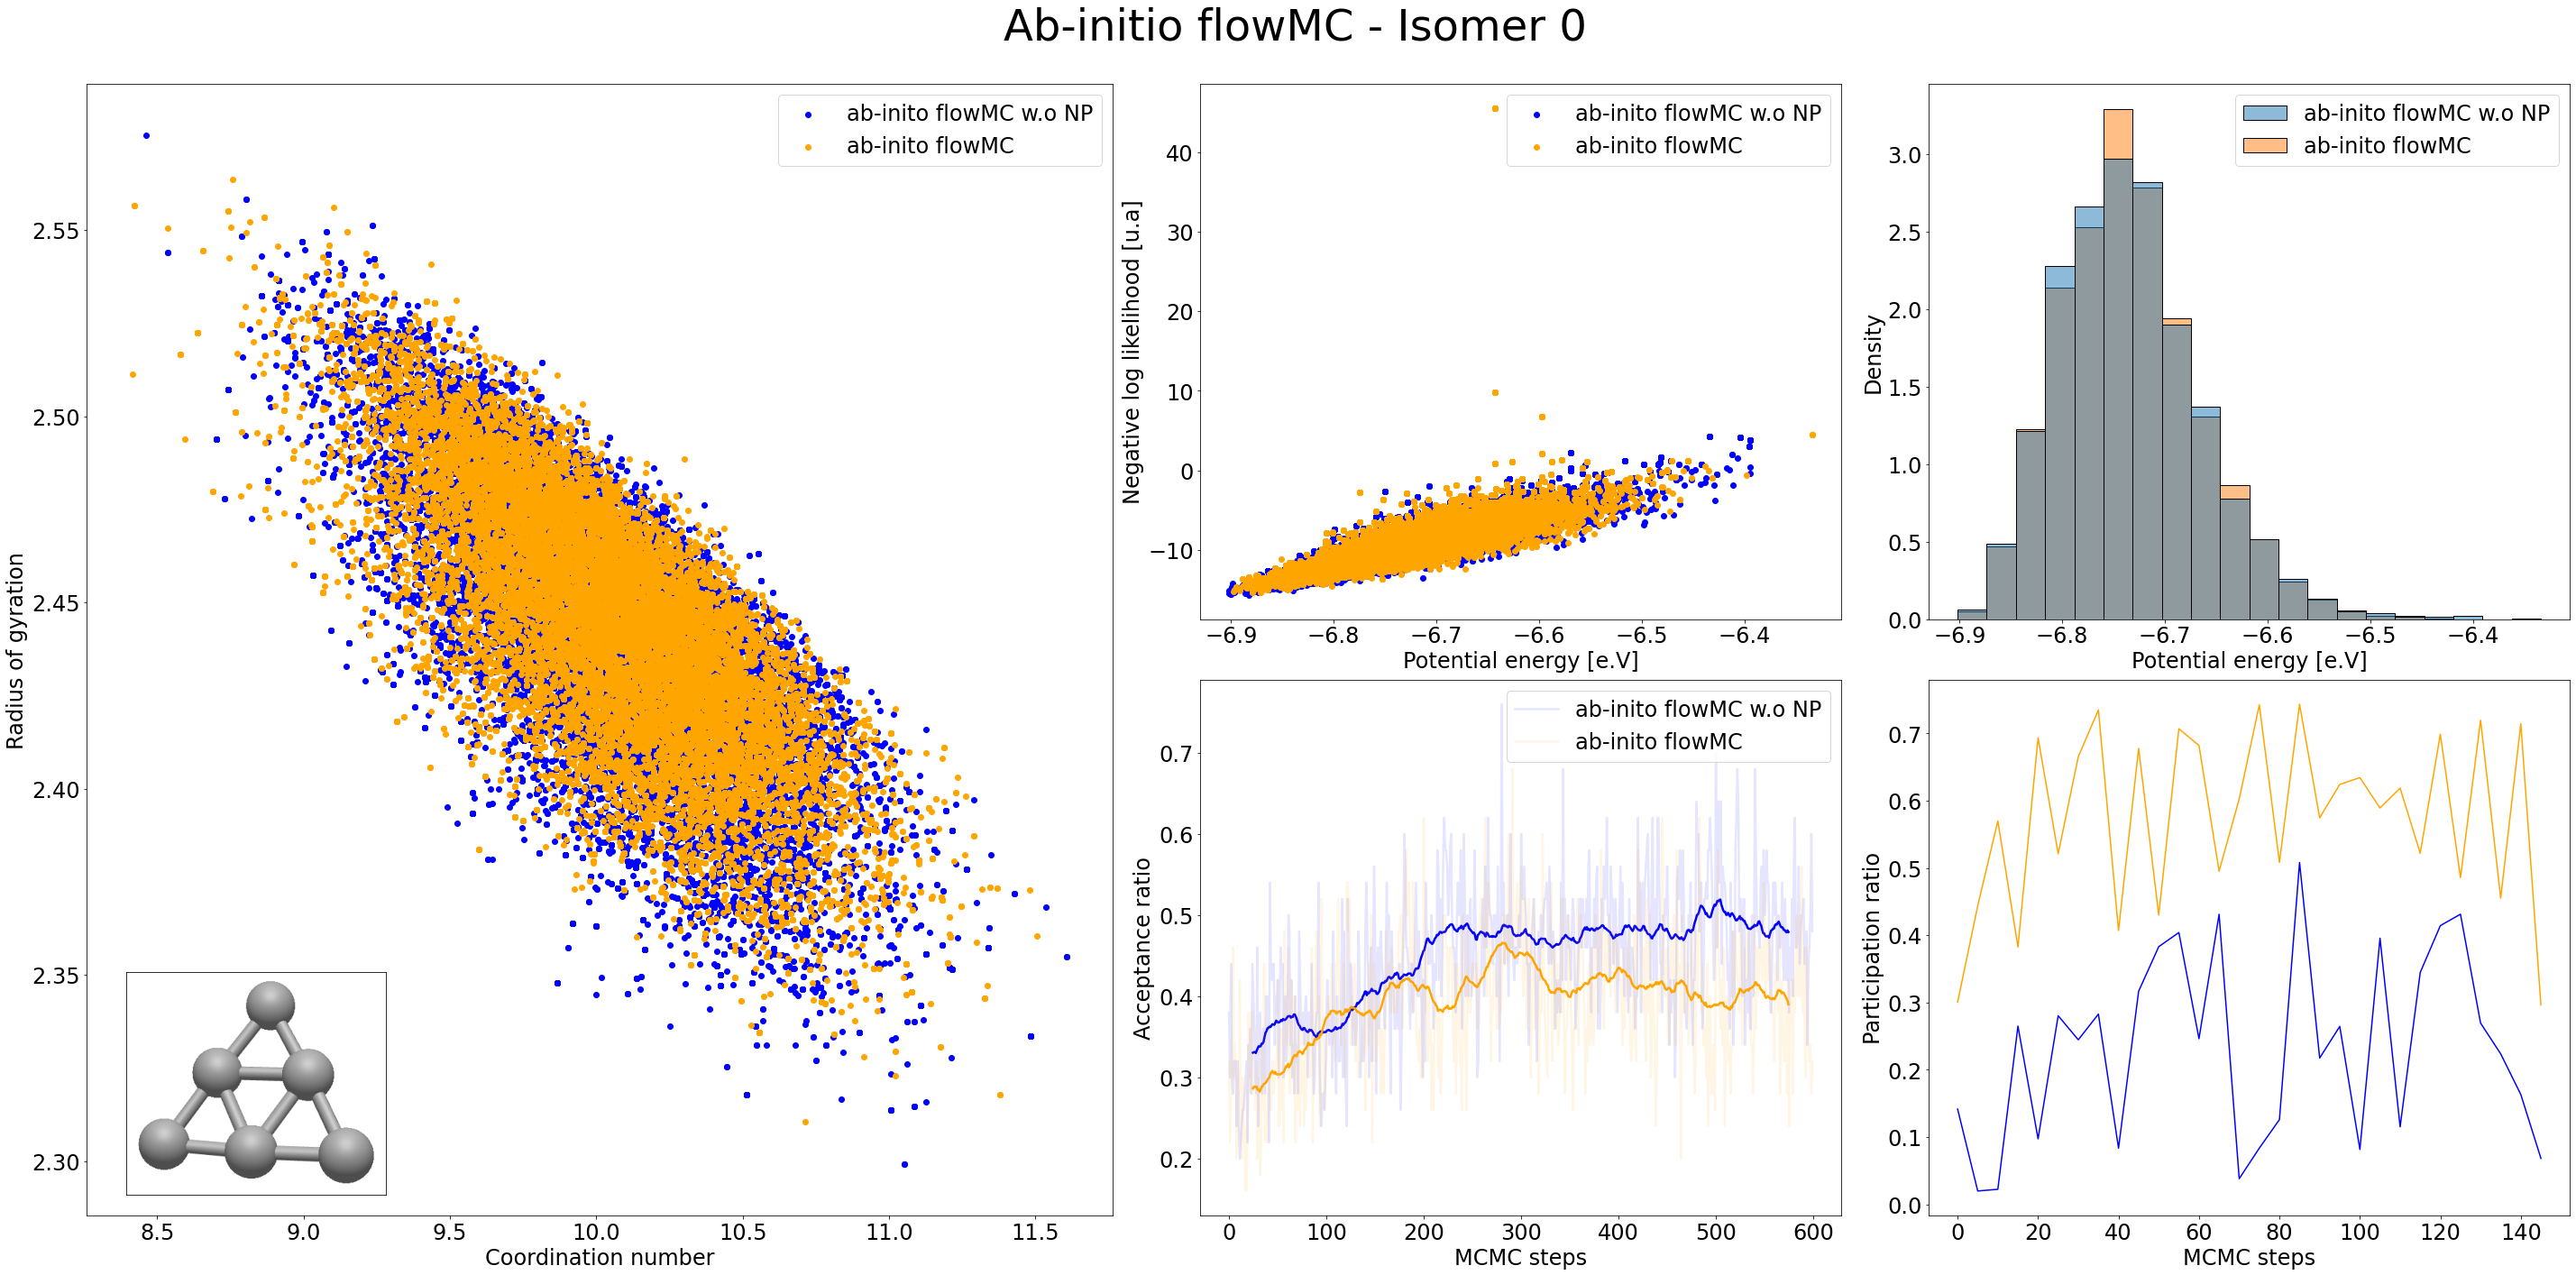

In [16]:
plot_figure_1(plot_data_is0, color_keys)

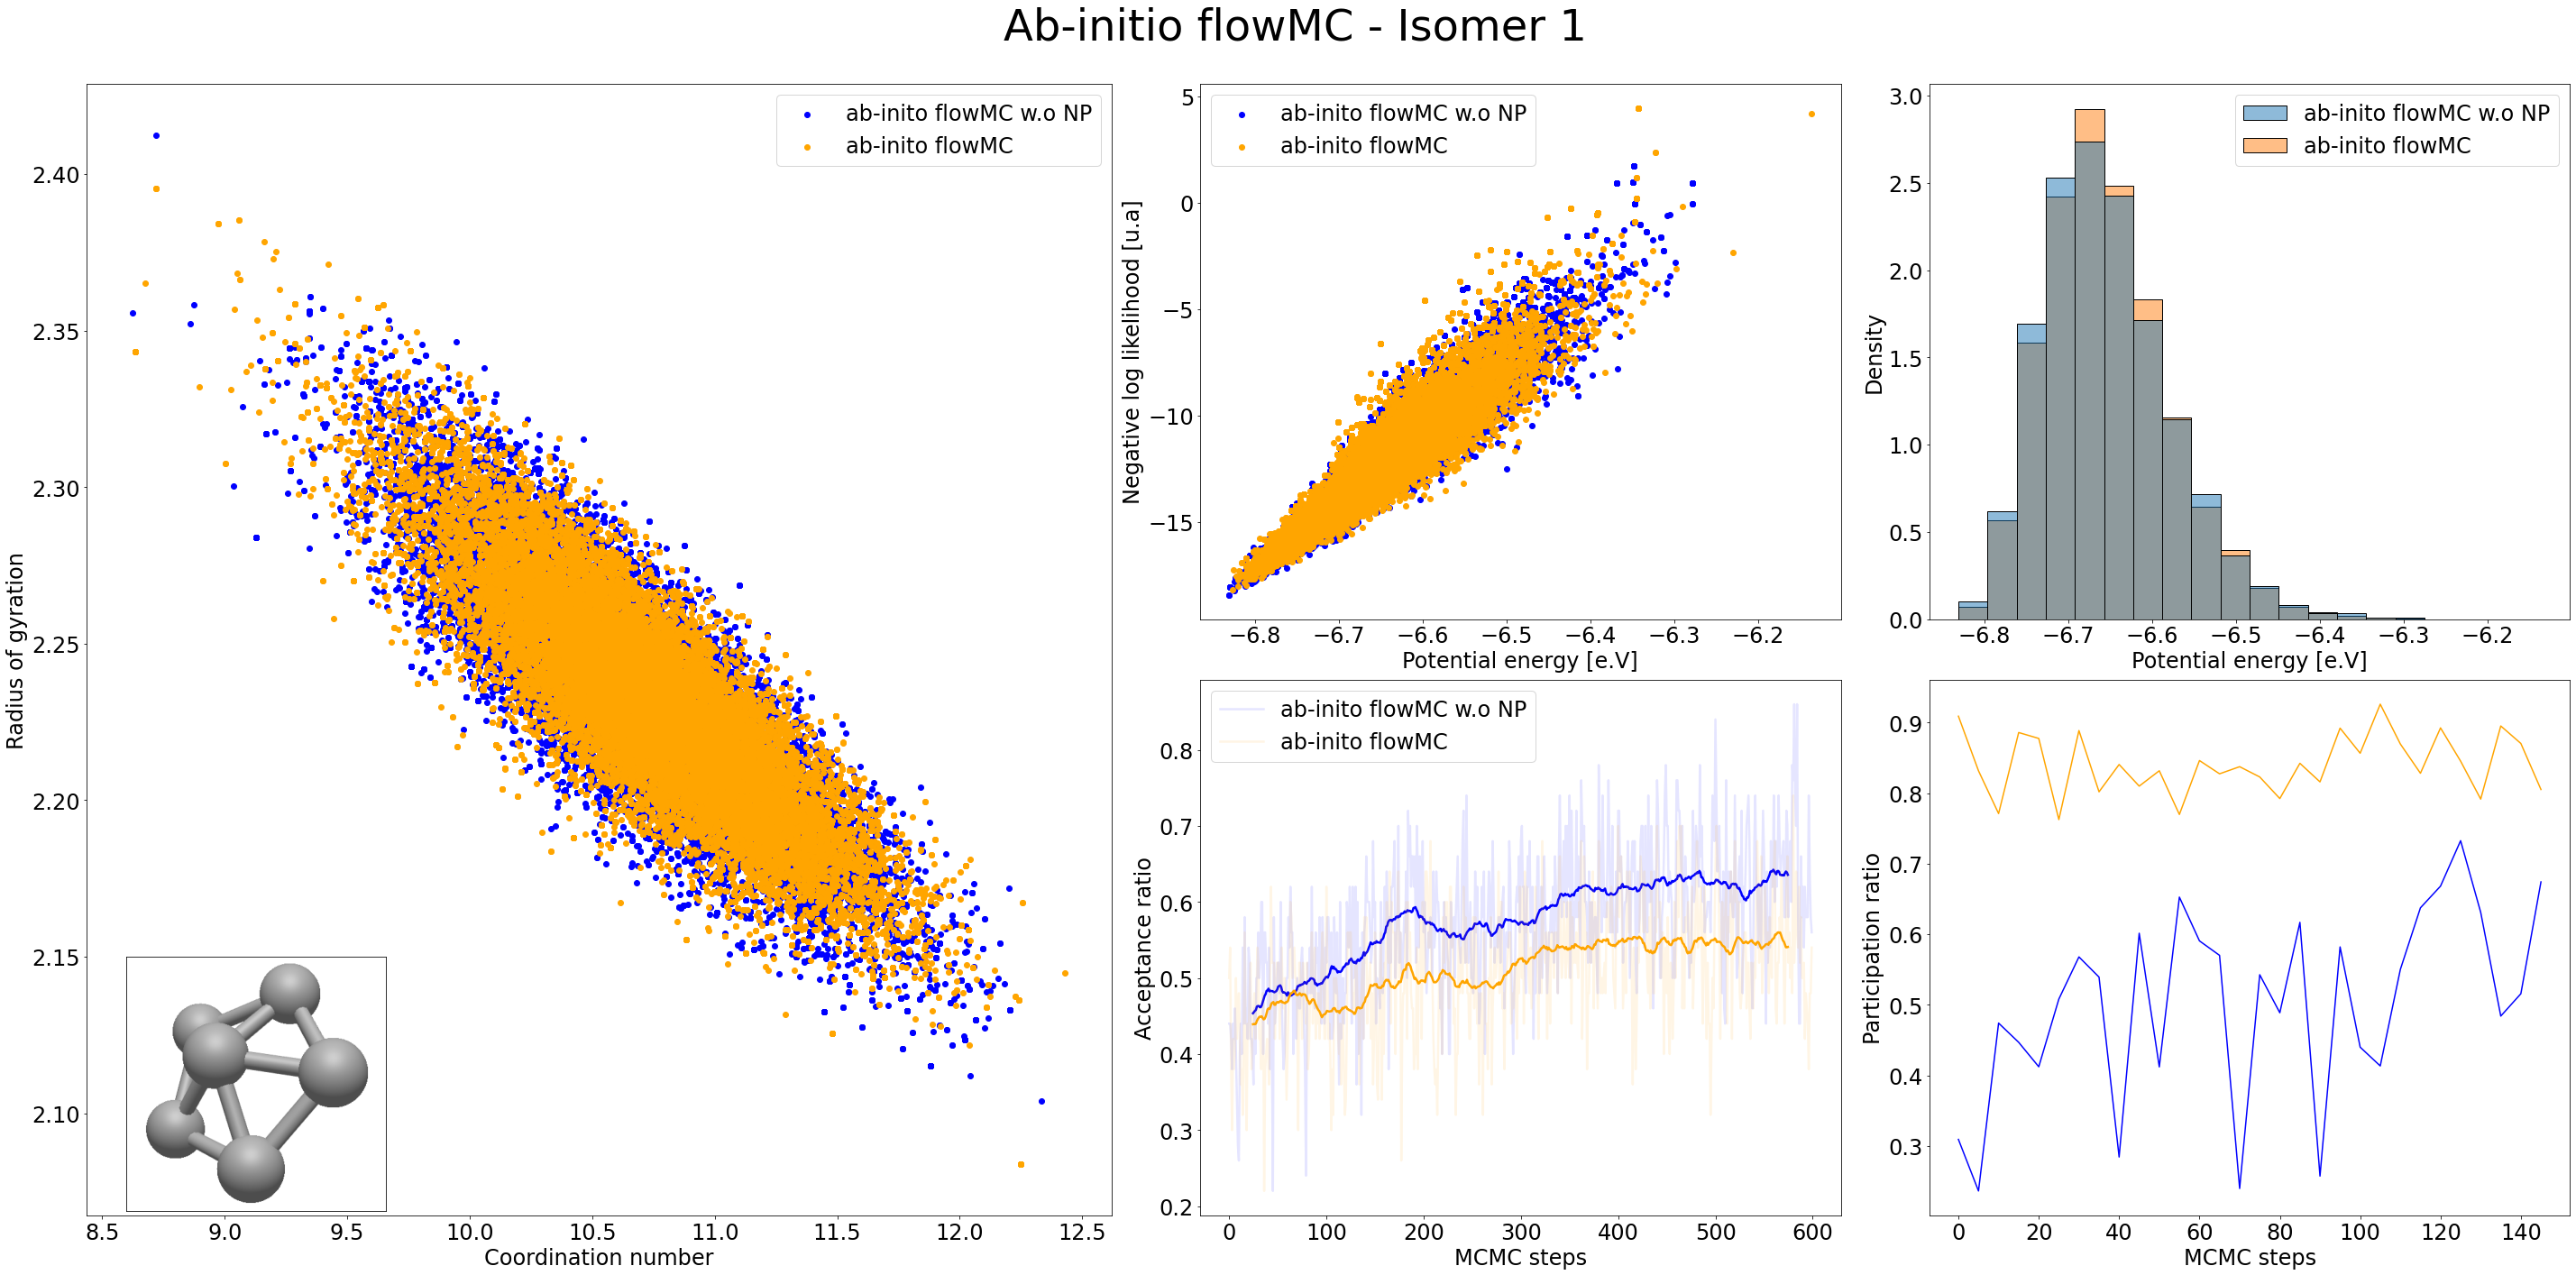

In [17]:
plot_figure_1(plot_data_is1, color_keys)

# Figure 2

In [18]:
# simulation files
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl']

# load mcmc results
keys = ['DFT-DFT', 'DFT-MLP', 'MLP-MLP']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, path) for mcmc_path, key in zip(mcmc_paths, keys)}

In [95]:
import seaborn as sns
import pandas as pd

In [113]:
torch.cat((adaptive_info_is0[keys[0]]['cvs'], 
            adaptive_info_is0[keys[0]]['us'].reshape(-1, 1)), dim=1)

tensor([[10.1974,  2.4536, -6.8278],
        [ 9.9752,  2.4721, -6.7160],
        [10.3937,  2.4362, -6.8327],
        ...,
        [10.9652,  2.3445, -6.7311],
        [10.2606,  2.4061, -6.6786],
        [ 9.9282,  2.4467, -6.8128]], dtype=torch.float64,
       grad_fn=<CatBackward0>)

In [115]:
cvs_data_0 = pd.DataFrame( torch.cat((adaptive_info_is0[keys[0]]['cvs'], 
            adaptive_info_is0[keys[0]]['us'].reshape(-1, 1)), dim=1).detach(),
                          columns=['C', 'R', 'E'])

cvs_data_1 = pd.DataFrame( torch.cat((adaptive_info_is1[keys[0]]['cvs'], 
            adaptive_info_is1[keys[0]]['us'].reshape(-1, 1)), dim=1).detach(),
                          columns=['C', 'R', 'E'])

cvs_data = pd.concat([cvs_data_0, cvs_data_1])

In [122]:
#ax.contour(cvs_data['C', 'R'], cvs_data['E'], levels=20, cmap='viridis')

KeyError: ('C', 'R')

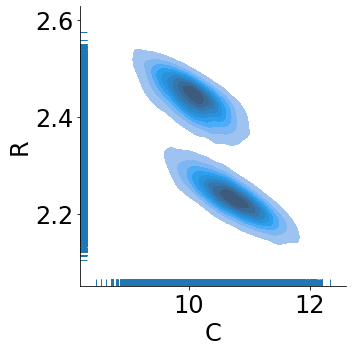

In [120]:
#fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 5))

#sns.displot(cvs_data, x='C', y='R', kind="kde", rug=True, fill=True)


In [1]:
#slides
from 

NameError: name 'get_path' is not defined

In [ ]:
xs_md = {i: load_csv_file("is{:d}_flow_train.csv".format(i), get_path()) for i in range(0, 3)}

In [ ]:
fig, ax = 